<a href="https://colab.research.google.com/github/angeruzzi/recommender_system_movielens/blob/main/04_content_based.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Content-Based Recommender — MovieLens 100K

## 1. Introdução

Este notebook implementa um sistema de recomendação baseado em conteúdo utilizando os gêneros dos filmes disponíveis no MovieLens 100K.

Em abordagens de **Content-Based Filtering**, os itens são representados por características descritivas e as recomendações são produzidas a partir da similaridade entre essas características e o perfil de preferência do usuário.

Neste experimento, cada filme será representado por um vetor binário de gêneros. O perfil de cada usuário será construído a partir dos filmes avaliados positivamente em seu histórico de treino.

A similaridade entre o perfil do usuário e os filmes candidatos será calculada utilizando similaridade por cosseno.

O modelo será avaliado com o mesmo protocolo temporal utilizado nos experimentos anteriores, permitindo comparação direta com os baselines Random e Popularity.

## 2. Preparação

In [8]:
#Imports

!wget -q -O utils.py \
    https://raw.githubusercontent.com/angeruzzi/recommender_system_movielens/main/utils.py

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import utils

#Validação
assert utils.validate_metrics()
assert utils.validate_framework()

print("Framework carregado com sucesso.")

#Configuração experimental:
RELEVANCE_THRESHOLD = 4
TRAIN_RATIO = 0.8
K = 10
RANDOM_STATE = 42

#Carregamento
ratings, movies = utils.load_movielens_100k()

print(f"Ratings: {len(ratings):,}")
print(f"Users:   {ratings['user_id'].nunique():,}")
print(f"Movies:  {ratings['item_id'].nunique():,}")

#Split
train, test = utils.temporal_split_by_user(
    ratings,
    train_ratio=TRAIN_RATIO
)

evaluation_data = utils.build_evaluation_data(
    train=train,
    test=test,
    relevance_threshold=RELEVANCE_THRESHOLD
)

train_catalog = evaluation_data["train_catalog"]
seen_items = evaluation_data["seen_items"]
ground_truth = evaluation_data["evaluable_ground_truth"]
evaluation_users = evaluation_data["evaluation_users"]

print(f"Train:              {len(train):,}")
print(f"Test:               {len(test):,}")
print(f"Evaluation users:   {len(evaluation_users):,}")
print(f"Train catalog:      {len(train_catalog):,}")

RESULTS_URL = "https://raw.githubusercontent.com/angeruzzi/recommender_system_movielens/main/model_results.csv"
model_results = pd.read_csv(RESULTS_URL)

Framework carregado com sucesso.
Ratings: 100,000
Users:   943
Movies:  1,682
Train:              79,619
Test:               20,381
Evaluation users:   907
Train catalog:      1,611


## 3. Representação dos Itens

Cada filme será representado por um vetor binário indicando os gêneros aos quais pertence.

Por exemplo, um filme classificado como Action e Sci-Fi pode ser representado conceitualmente como:

\[
[1,0,0,\ldots,1,\ldots]
\]

Essa representação permite comparar itens e perfis de usuários em um espaço comum de características.

In [9]:
genre_columns = utils.GENRES

movie_features = (
    movies[
        movies["item_id"].isin(train_catalog)
    ]
    .set_index("item_id")[genre_columns]
    .astype(float)
)

movie_features.head()

,unknown,Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
item_id,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [10]:
print(
    f"Item feature matrix: "
    f"{movie_features.shape[0]} × {movie_features.shape[1]}"
)

Item feature matrix: 1611 × 19


In [11]:
#Normalização

item_norms = np.linalg.norm(
    movie_features.values,
    axis=1,
    keepdims=True
)

item_norms[item_norms == 0] = 1

movie_features_normalized = pd.DataFrame(
    movie_features.values / item_norms,
    index=movie_features.index,
    columns=movie_features.columns
)

movie_features_normalized.head()

,unknown,Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
item_id,,,,,,,,,,,,,,,,,,,
1,0.0,0.00000,0.00000,0.57735,0.57735,0.57735,0.00000,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0
2,0.0,0.57735,0.57735,0.00000,0.00000,0.00000,0.00000,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.57735,0.0,0.0
3,0.0,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.00000,0.0,0.0
4,0.0,0.57735,0.00000,0.00000,0.00000,0.57735,0.00000,0.0,0.57735,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0
5,0.0,0.00000,0.00000,0.00000,0.00000,0.00000,0.57735,0.0,0.57735,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.57735,0.0,0.0


## 4. Construção do Perfil do Usuário

O perfil de preferência de cada usuário será construído utilizando apenas os filmes considerados relevantes no conjunto de treino.

Para cada usuário, os vetores de gênero dos filmes avaliados com rating igual ou superior a 4 serão combinados por meio de uma média.

O vetor resultante representa a distribuição relativa das características presentes nos itens preferidos pelo usuário.

In [12]:
positive_train = train[
    train["rating"] >= RELEVANCE_THRESHOLD
].copy()

In [13]:
def build_user_profile(
    user_id,
    positive_train,
    movie_features
):
    user_items = positive_train.loc[
        positive_train["user_id"] == user_id,
        "item_id"
    ]

    user_items = [
        item_id
        for item_id in user_items
        if item_id in movie_features.index
    ]

    if len(user_items) == 0:
        return None

    profile = (
        movie_features
        .loc[user_items]
        .mean(axis=0)
        .values
    )

    norm = np.linalg.norm(profile)

    if norm == 0:
        return None

    return profile / norm

In [14]:
user_id = evaluation_users[0]

profile = build_user_profile(
    user_id=user_id,
    positive_train=positive_train,
    movie_features=movie_features
)

profile

array([0.01055913, 0.38012855, 0.1583869 , 0.04223651, 0.05279563,
       0.41180593, 0.11615039, 0.03167738, 0.64410671, 0.01055913,
       0.01055913, 0.06335476, 0.05279563, 0.03167738, 0.23230078,
       0.28509641, 0.25341903, 0.13726864, 0.02111825])

## 5. Cálculo de Similaridade

A similaridade entre o perfil do usuário e cada filme candidato será calculada utilizando similaridade por cosseno.

Como os vetores de usuários e itens estão normalizados, o produto escalar entre eles equivale à similaridade por cosseno.

\[
score(u,i) = \cos(\mathbf{u}, \mathbf{i})
\]

Valores maiores indicam maior alinhamento entre o perfil de preferência do usuário e as características do filme.

In [15]:
def score_candidate_items(
    user_id,
    positive_train,
    movie_features,
    train_catalog,
    seen_items
):
    profile = build_user_profile(
        user_id=user_id,
        positive_train=positive_train,
        movie_features=movie_features
    )

    if profile is None:
        return pd.Series(dtype=float)

    candidates = utils.get_candidate_items(
        user_id=user_id,
        train_catalog=train_catalog,
        seen_items=seen_items
    )

    candidates = [
        item_id
        for item_id in candidates
        if item_id in movie_features.index
    ]

    if len(candidates) == 0:
        return pd.Series(dtype=float)

    candidate_matrix = (
        movie_features_normalized
        .loc[candidates]
    )

    scores = candidate_matrix.values @ profile

    return pd.Series(
        scores,
        index=candidate_matrix.index,
        name="score"
    ).sort_values(ascending=False)

In [16]:
#Teste
user_id = evaluation_users[0]

user_scores = score_candidate_items(
    user_id=user_id,
    positive_train=positive_train,
    movie_features=movie_features,
    train_catalog=train_catalog,
    seen_items=seen_items
)

user_scores.head(10)

,score
item_id,
74,0.829099
1138,0.776096
337,0.755943
1631,0.746643
737,0.746643
1626,0.746643
1627,0.746643
856,0.746643
1557,0.746643


## 6. Geração das Recomendações Top-K

Para cada usuário elegível, os itens candidatos serão ordenados pelo score de similaridade com seu perfil.

Os \(K\) itens com maior score formarão a lista final de recomendações.

In [17]:
content_recommendations = {}

for user_id in evaluation_users:
    scores = score_candidate_items(
        user_id=user_id,
        positive_train=positive_train,
        movie_features=movie_features,
        train_catalog=train_catalog,
        seen_items=seen_items
    )

    content_recommendations[user_id] = (
        scores
        .head(K)
        .index
        .tolist()
    )

In [18]:
lengths = [
    len(items)
    for items in content_recommendations.values()
]

print(f"Mínimo de recomendações: {min(lengths)}")
print(f"Máximo de recomendações: {max(lengths)}")

Mínimo de recomendações: 10
Máximo de recomendações: 10


In [19]:
#Exemplo

user_id = evaluation_users[0]

recommended_ids = content_recommendations[user_id]

recommended_movies = (
    pd.DataFrame({
        "item_id": recommended_ids,
        "rank": range(1, len(recommended_ids) + 1)
    })
    .merge(
        movies[
            ["item_id", "title"] + genre_columns
        ],
        on="item_id",
        how="left"
    )
    .sort_values("rank")
)

recommended_movies[
    ["rank", "item_id", "title"]
]

,rank,item_id,title
0,1,74,Faster Pussycat! Kill! Kill! (1965)
1,2,1138,Best Men (1997)
2,3,337,"House of Yes, The (1997)"
3,4,1631,"Slingshot, The (1993)"
4,5,737,Sirens (1994)
5,6,1626,Nobody Loves Me (Keiner liebt mich) (1994)
6,7,1627,"Wife, The (1995)"
7,8,856,Night on Earth (1991)
8,9,1557,Yankee Zulu (1994)
9,10,789,Swimming with Sharks (1995)


## 7. Avaliação

As recomendações geradas pelo modelo Content-Based serão avaliadas utilizando o mesmo ground truth e as mesmas métricas empregadas nos baselines.

Dessa forma, qualquer diferença de desempenho pode ser atribuída ao modelo e não a mudanças no protocolo experimental.

In [20]:
content_results, content_summary = (
    utils.evaluate_recommendations(
        recommendations=content_recommendations,
        ground_truth=ground_truth,
        k=K
    )
)

content_summary

{'Precision@10': np.float64(0.01896361631753032),
 'Recall@10': np.float64(0.018317689291791426),
 'NDCG@10': np.float64(0.025018420803613026),
 'n_users': 907}

In [21]:
comparison = utils.add_model_result(
    results_df=model_results,
    model_name="Content-Based",
    summary=content_summary,
    k=K
)

comparison

,model,Precision@10,Recall@10,NDCG@10,n_users
0,Random,0.007387,0.006949,0.008209,907
1,Popularity,0.077508,0.078646,0.098883,907
2,Content-Based,0.018964,0.018318,0.025018,907


## 9. Interpretação do Perfil do Usuário

Uma vantagem de modelos baseados em conteúdo é a possibilidade de interpretar diretamente quais características contribuíram para as recomendações.

Como o perfil do usuário está representado no mesmo espaço de gêneros dos filmes, é possível identificar quais categorias possuem maior peso em seu histórico positivo.

In [22]:
user_id = evaluation_users[0]

profile = build_user_profile(
    user_id,
    positive_train,
    movie_features
)

profile_df = pd.DataFrame({
    "genre": genre_columns,
    "weight": profile
}).sort_values(
    "weight",
    ascending=False
)

profile_df

,genre,weight
8,Drama,0.644107
5,Comedy,0.411806
1,Action,0.380129
15,Sci-Fi,0.285096
16,Thriller,0.253419
14,Romance,0.232301
2,Adventure,0.158387
17,War,0.137269
6,Crime,0.116150
11,Horror,0.063355


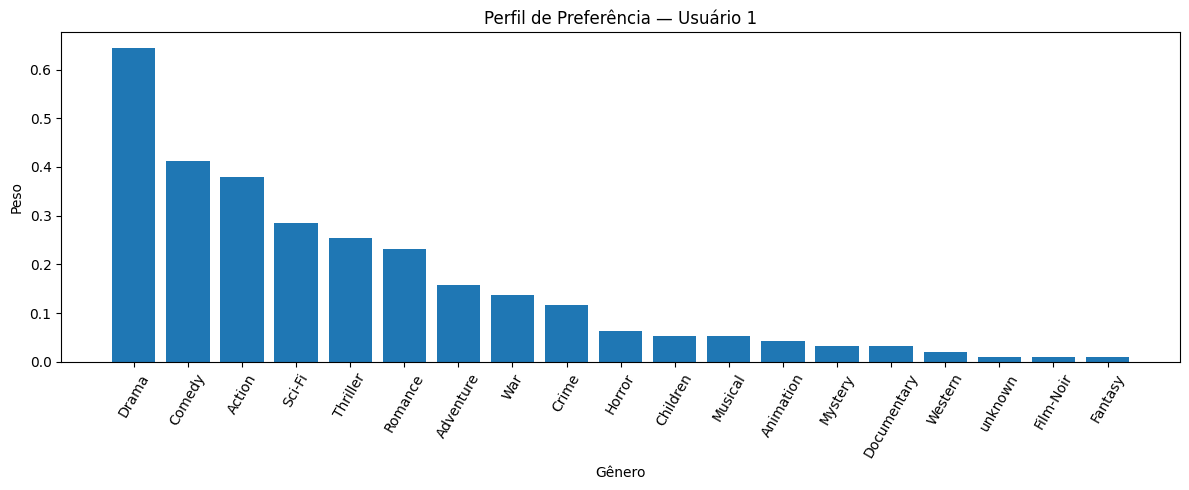

In [23]:
plt.figure(figsize=(12, 5))

plt.bar(
    profile_df["genre"],
    profile_df["weight"]
)

plt.title(
    f"Perfil de Preferência — Usuário {user_id}"
)
plt.xlabel("Gênero")
plt.ylabel("Peso")
plt.xticks(rotation=60)
plt.tight_layout()

plt.show()

## 10. Limitações do Modelo

O modelo Content-Based implementado utiliza apenas os gêneros dos filmes como atributos.

Isso torna a abordagem simples e interpretável, mas também limita sua capacidade de capturar preferências mais específicas.

Filmes com vetores de gênero idênticos recebem scores muito semelhantes, mesmo que possuam diferenças importantes de diretor, atores, estilo, período ou temática.

Além disso, o modelo tende a recomendar itens semelhantes ao histórico existente do usuário, podendo reduzir diversidade e descoberta de conteúdos fora de seus padrões anteriores.

Apesar dessas limitações, a abordagem possui uma vantagem importante em relação a modelos puramente colaborativos: itens novos podem ser recomendados desde que seus atributos de conteúdo estejam disponíveis.

## 11. Conclusões

Neste experimento foi implementado um sistema de recomendação Content-Based utilizando os gêneros dos filmes como representação de conteúdo.

O histórico de avaliações positivas foi utilizado para construir um perfil vetorial para cada usuário, e a similaridade por cosseno permitiu ordenar os filmes candidatos de acordo com a proximidade entre suas características e as preferências observadas.

O modelo foi avaliado utilizando o mesmo protocolo temporal e as mesmas métricas dos baselines, permitindo comparação direta entre estratégias aleatórias, baseadas em popularidade e personalizadas por conteúdo.

A próxima etapa será explorar **Collaborative Filtering**, utilizando padrões de interação entre usuários e itens em vez de atributos explícitos dos filmes.